In [7]:
!pip install imbalanced-learn

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [9]:
# تحميل البيانات
df = pd.read_csv(r"E:\Depi\Template\asthma_disease_data.csv")

In [10]:
# --- تنظيف البيانات ---
df.dropna(inplace=True)  # إزالة القيم الفارغة
df = df.select_dtypes(include=[np.number])  # الاحتفاظ بالبيانات الرقمية فقط

In [11]:
# --- Feature Importance باستخدام RandomForest ---
X = df.drop(columns=["Diagnosis"])  # الميزات
y = df["Diagnosis"]  # المتغير المستهدف

In [12]:
# تحويل المتغير المستهدف إذا كان غير رقمي
if y.dtype == "O":
    y = LabelEncoder().fit_transform(y)

In [13]:
# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

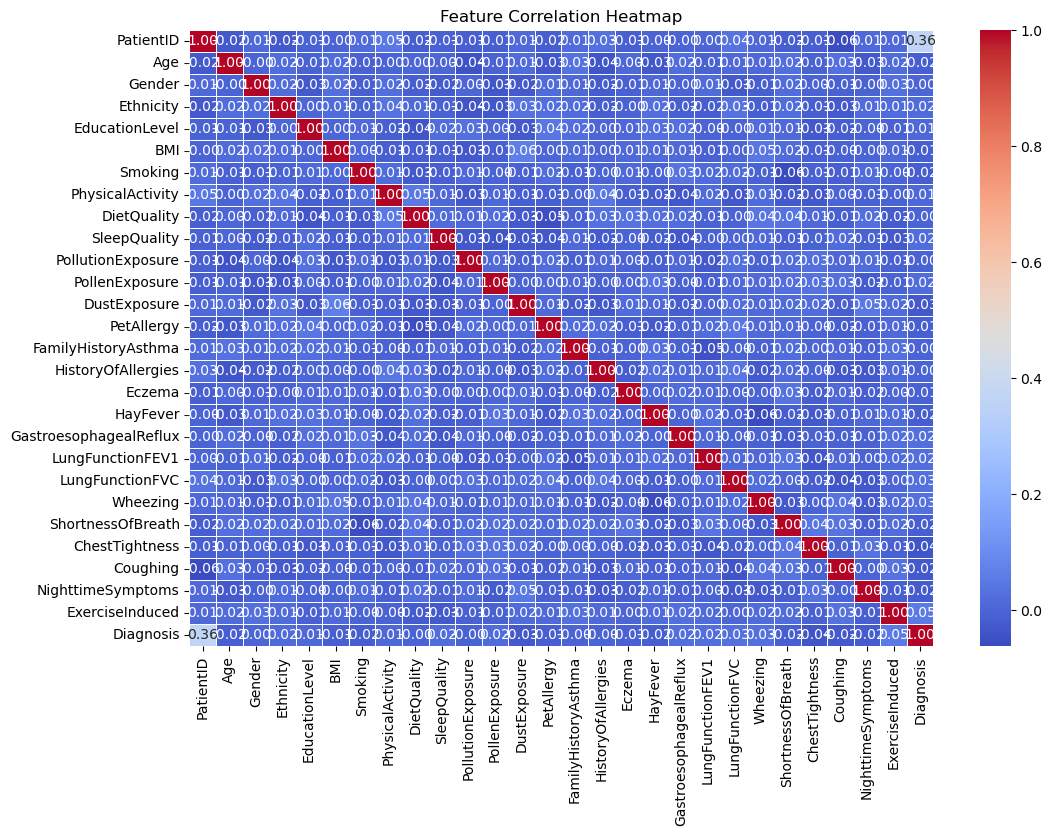

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# --- Predictive Power ---
if "Diagnosis" in df.columns:
    correlations = df.corr()["Diagnosis"].drop("Diagnosis").sort_values(ascending=False)
    print("Predictive Power of Features:\n", correlations)

Predictive Power of Features:
 PatientID                 0.364879
ExerciseInduced           0.053956
LungFunctionFVC           0.029629
Wheezing                  0.027197
LungFunctionFEV1          0.023336
GastroesophagealReflux    0.022770
SleepQuality              0.018022
Ethnicity                 0.017124
PollenExposure            0.015099
EducationLevel            0.008185
PhysicalActivity          0.005066
Gender                    0.003128
FamilyHistoryAsthma      -0.001334
HistoryOfAllergies       -0.001951
DietQuality              -0.003149
PollutionExposure        -0.004535
Eczema                   -0.008592
BMI                      -0.012522
PetAllergy               -0.013078
Age                      -0.015111
ShortnessOfBreath        -0.015281
HayFever                 -0.019141
Smoking                  -0.019321
NighttimeSymptoms        -0.021965
Coughing                 -0.024193
DustExposure             -0.025972
ChestTightness           -0.039278
Name: Diagnosis, dtype: 

In [16]:
# استبعاد الميزات غير المفيدة وإضافة ميزات أكثر أهمية
features_to_plot = ["LungFunctionFVC", "BMI", "PhysicalActivity", "Wheezing", "LungFunctionFEV1", "Diagnosis"]
df_filtered = df[features_to_plot]

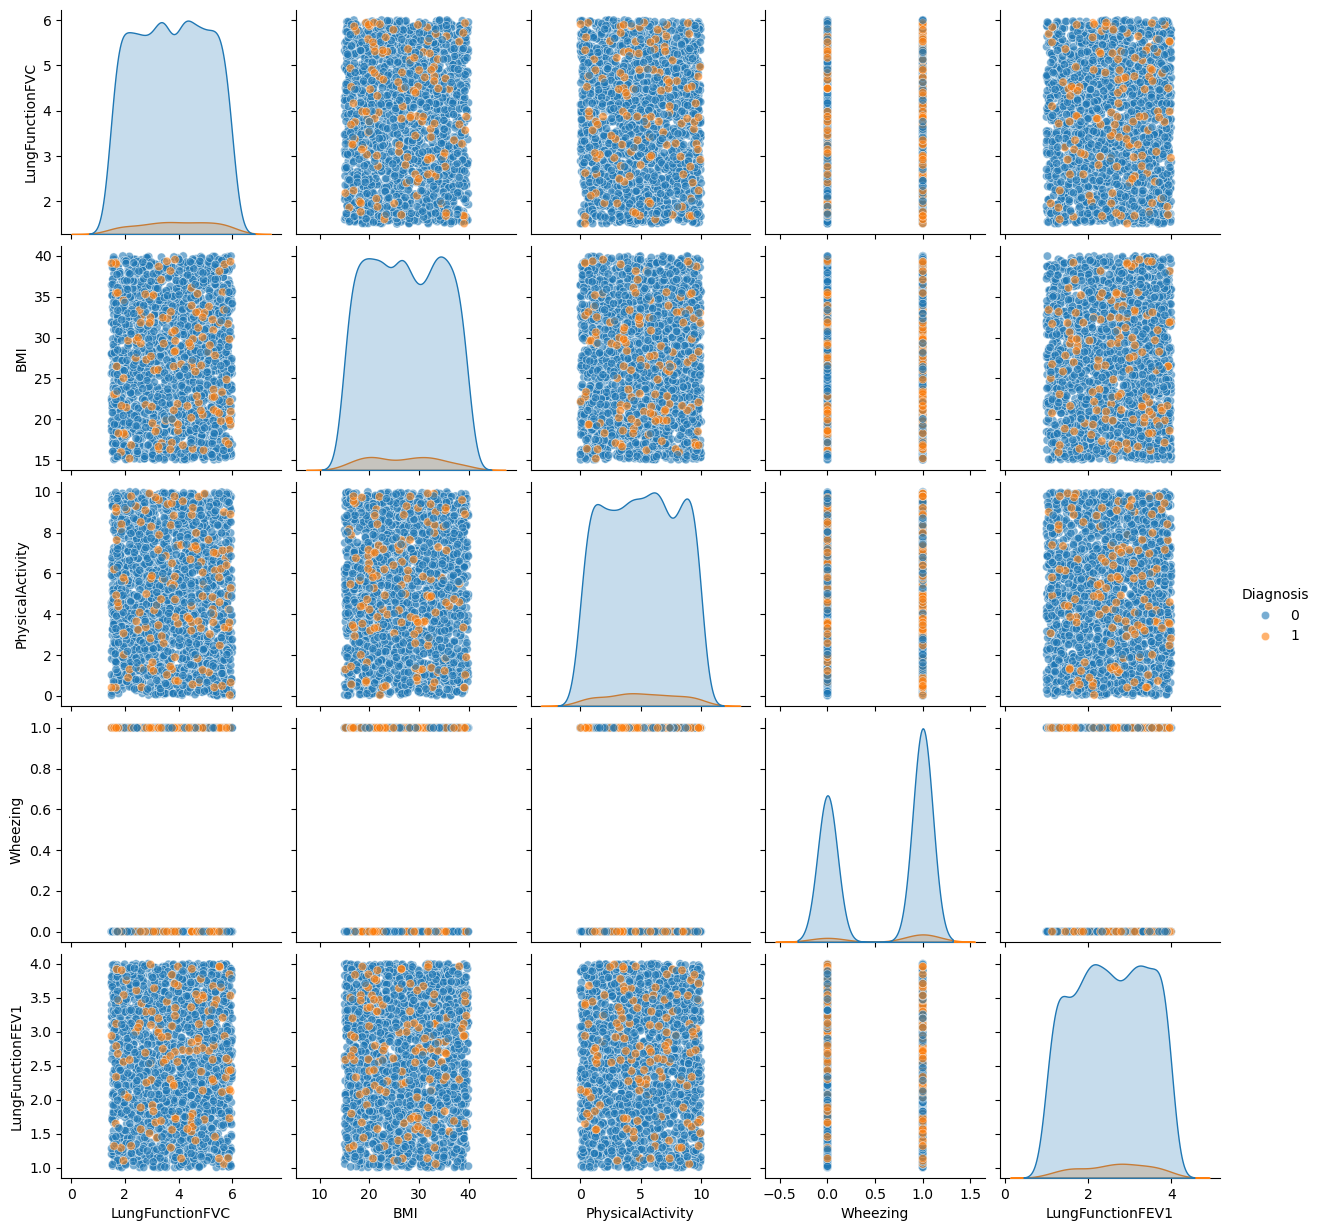

In [17]:
sns.pairplot(df_filtered, hue="Diagnosis", plot_kws={'alpha': 0.6})
plt.show()

In [18]:
# Feature Importance باستخدام Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_
feature_names = X.columns
sorted_indices = np.argsort(importances)[::-1]

C:\Users\mtawf\AppData\Local\Temp\ipykernel_11424\1212411191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[sorted_indices], y=np.array(feature_names)[sorted_indices], palette="viridis", dodge=False)


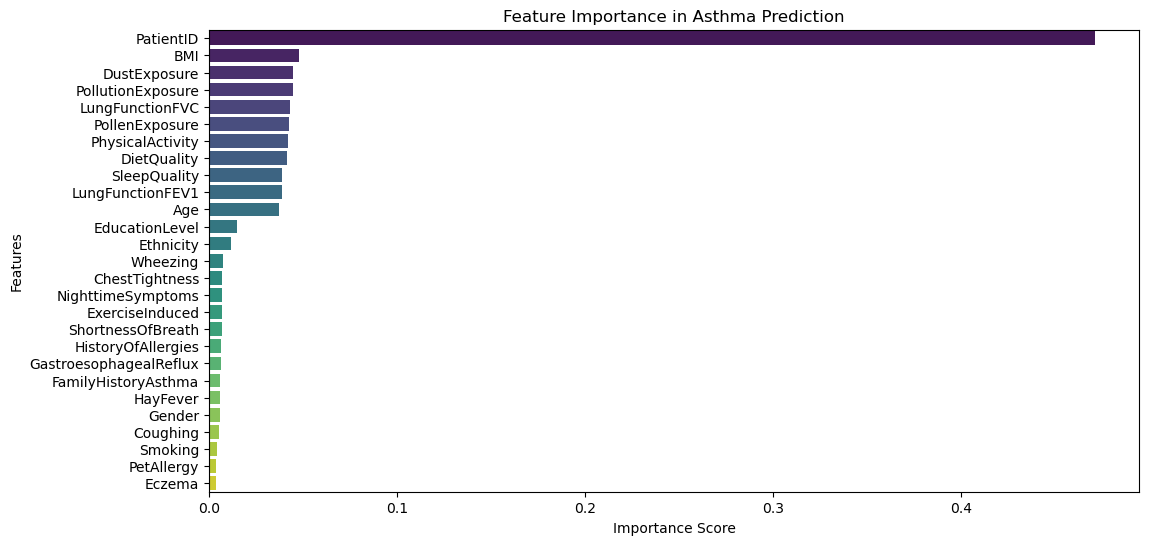

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[sorted_indices], y=np.array(feature_names)[sorted_indices], palette="viridis", dodge=False)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Asthma Prediction")
plt.show()

C:\Users\mtawf\AppData\Local\Temp\ipykernel_11424\3653901445.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="magma", dodge=False)


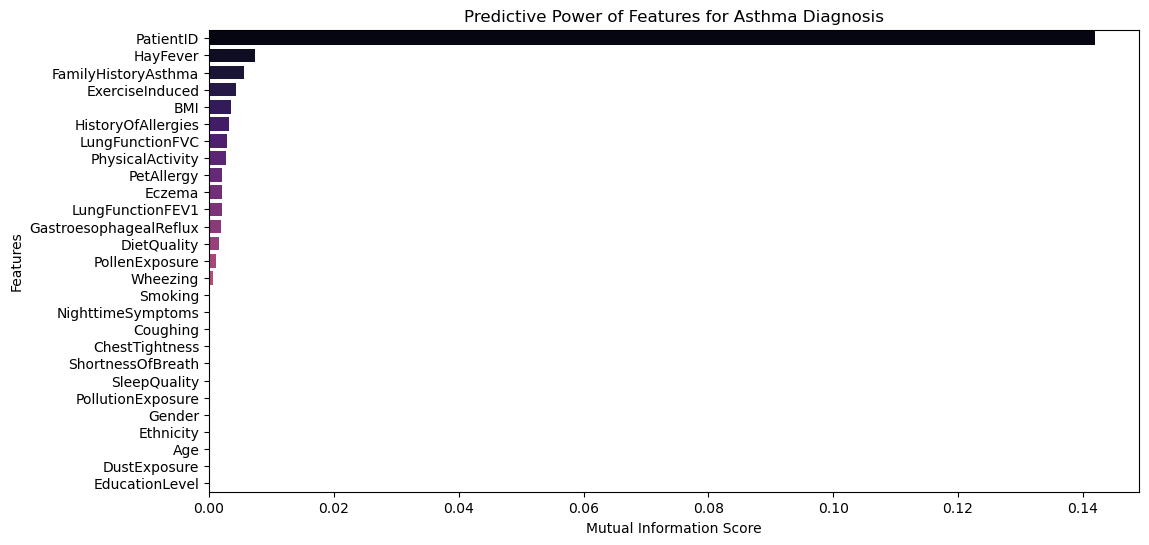

In [20]:
# mutual information
mi_scores = mutual_info_classif(X_train, y_train)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="magma", dodge=False)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Predictive Power of Features for Asthma Diagnosis")
plt.show()

In [21]:
# SMOTE لتوازن البيانات
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Original dataset shape:", Counter(y))
print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 2268, 1: 124})
Resampled dataset shape: Counter({0: 2268, 1: 2268})


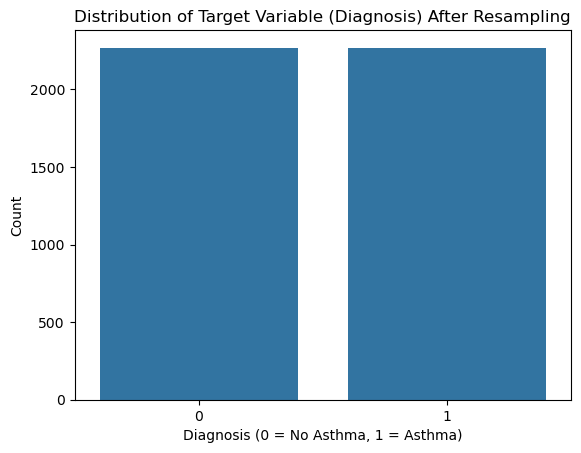

In [22]:
# توزيع المتغير الهدف
sns.countplot(x=y_resampled)
plt.title("Distribution of Target Variable (Diagnosis) After Resampling")
plt.xlabel("Diagnosis (0 = No Asthma, 1 = Asthma)")
plt.ylabel("Count")
plt.show()

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# تعريف الموديل
model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# تجميع الموديل
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# تدريب الموديل
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10


c:\Users\mtawf\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4254 - loss: 281.9945 - val_accuracy: 0.9520 - val_loss: 18.8761
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9399 - loss: 14.6796 - val_accuracy: 0.9353 - val_loss: 0.3453
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8746 - loss: 0.7268 - val_accuracy: 0.9520 - val_loss: 0.3834
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9249 - loss: 0.4389 - val_accuracy: 0.9353 - val_loss: 0.3154
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9084 - loss: 0.5119 - val_accuracy: 0.9520 - val_loss: 1.7480
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8970 - loss: 1.3463 - val_accuracy: 0.9520 - val_loss: 1.1557
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8916 - loss: 0.9861 - val_accuracy: 0.9457 - val_loss: 0.3086
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9114 - loss: 0.4221 - val_accuracy: 0.6430 - val_loss: 0.8382

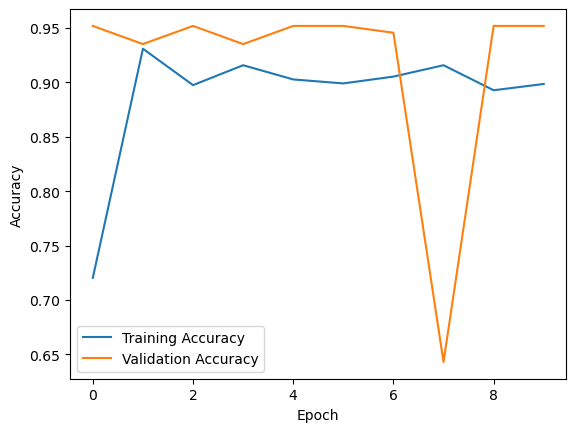

In [24]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9408 - loss: 0.4458 
Test Accuracy: 0.9520


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


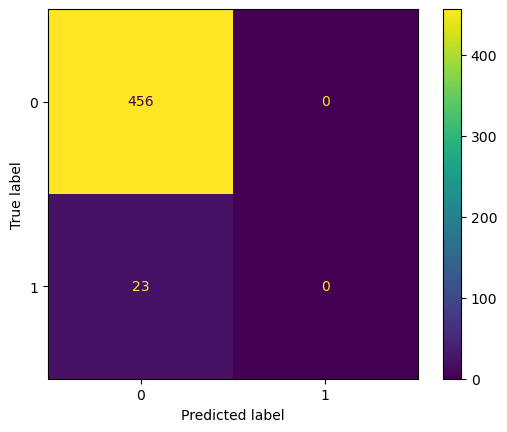

In [26]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [27]:
y_probs = model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


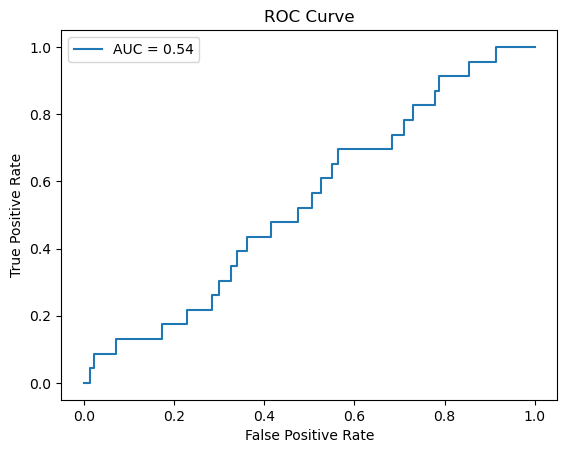

In [28]:
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [38]:
# ✅ حفظ الموديل بصيغة H5 و PKL
from tensorflow.keras.models import load_model
import pickle

# تأكد إن الموديل مدرب (model موجود بالفعل هنا)
model.save("saved_model/asthma_diagnosis_model.h5")
print("✅ Model saved as .h5 format")

# حفظ المسار في ملف .pkl
with open("saved_model/asthma_model_path.pkl", "wb") as file:
    pickle.dump("saved_model/asthma_diagnosis_model.h5", file)

print("✅ Model path saved as .pkl file")

# ✅ تحميل الموديل من المسار المحفوظ في .pkl
with open("saved_model/asthma_model_path.pkl", "rb") as file:
    model_path = pickle.load(file)

loaded_model = load_model(model_path)
loaded_model.summary()

# ✅ اختبار الموديل
# تأكد إنك معرف X_test و y_test قبل ده (ومحضرهم صح)
test_loss, test_acc = loaded_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")


✅ Model saved as .h5 format
✅ Model path saved as .pkl file


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9408 - loss: 0.4458  
Test Accuracy: 0.9519832730293274


In [39]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'PollutionExposure', 'PollenExposure', 'DustExposure', 'PetAllergy',
       'FamilyHistoryAsthma', 'HistoryOfAllergies', 'Eczema', 'HayFever',
       'GastroesophagealReflux', 'LungFunctionFEV1', 'LungFunctionFVC',
       'Wheezing', 'ShortnessOfBreath', 'ChestTightness', 'Coughing',
       'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis'],
      dtype='object')